# Vision Pipeline Validation

Diagnostic notebook to validate that the rodent's egocentric vision produces
meaningful gap information and flows correctly through the CNN to the policy.

**Checks:**
1. Raw rendered images are non-trivial (not blank/constant)
2. Gap is visible in egocentric camera
3. CNN features respond to visual changes
4. Policy outputs change with different vision inputs

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import collections
import jax
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mujoco
import numpy as np
from tqdm import tqdm

from vnl_playground.tasks.rodent import run_gap_vision
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from track_mjx.agent.ff_ppo.vision_encoder import VisionEncoder
from track_mjx.agent.observation_utils import flatten_obs_dict

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


In [2]:
# Create env matching training config: run_gap_vision_transfer.yaml
from ml_collections import config_dict as mlc_config_dict

cfg = run_gap_vision.default_config()
cfg.target_speed = 0.5
cfg.platform_length_range = (0.3, 0.6)
cfg.gap_length_range = (0.03, 0.12)
cfg.n_platforms = 20
cfg.torque_actuators = True
cfg.vision_width = 32
cfg.vision_height = 32
cfg.grayscale = True
cfg.vision_camera_name = "egocentric-rodent"

env = run_gap_vision.RunGapVision(config=cfg)
mj_model = env.mj_model

print(f"Vision shape: {env.vision_shape}")
print(f"Action size: {env.action_size}")
print(f"Proprioceptive obs size: {env.proprioceptive_obs_size}")

# Reset to get initial state
rng = jax.random.PRNGKey(42)
state = jax.jit(env.reset)(rng)
print(f"Obs keys: {list(state.obs.keys())}")
print(f"State keys: {list(state.obs['state'].keys())}")
print(f"Vision placeholder shape: {state.obs['state']['vision'].shape}")
print(
    f"Vision placeholder stats: min={float(state.obs['state']['vision'].min())}, "
    f"max={float(state.obs['state']['vision'].max())}"
)
print("  -> These should be zeros (placeholder, not yet rendered)")

Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.11.0
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.types.array` will soon be removed from the public API. Use `warp.array` instead.
Vision shape: (32, 32, 1)
Action size: 38
Module mujoco.mjx.third_party.mujoco_warp._src.smooth e142b0f load on device 'cuda:0' took 9.65 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver de6dc98 load on device 'cuda:0' took 0.93 ms  (cached)
Module _nxn_broadphase__locals__kernel_8c837afb 8c837af load on device 'cuda:0' took 1.10 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_d1f

## 1. Raw Vision Rendering Check

Create the GPU renderer (same as training) and verify it produces non-trivial images.

In [3]:
# Create JAX vision renderer (same as training pipeline uses)
renderer = JaxVisionRenderer(
    mj_model=mj_model,
    nworld=1,  # single world for inspection
    width=32,
    height=32,
    grayscale=True,
    camera_name="egocentric-rodent",
)

# Render from the initial state
# JaxVisionRenderer.render() expects mjx.Data with batch dim
batched_data = jax.tree.map(lambda x: x[None, ...], state.data)
vision_initial = renderer.render(batched_data)
print(f"Rendered vision shape: {vision_initial.shape}")
print(f"Rendered vision dtype: {vision_initial.dtype}")
print(
    f"Rendered vision range: [{float(vision_initial.min()):.4f}, {float(vision_initial.max()):.4f}]"
)
print(f"Rendered vision mean: {float(vision_initial.mean()):.4f}")
print(f"Rendered vision std: {float(vision_initial.std()):.4f}")

is_trivial = float(vision_initial.std()) < 1e-6
print(
    f"\nVISION IS {'TRIVIAL (ALL SAME VALUE)' if is_trivial else 'NON-TRIVIAL (has variation)'}"
)
if is_trivial:
    print("  WARNING: The rendered image has no variation - something is wrong!")

Module mujoco_warp._src.smooth 78e7453 load on device 'cuda:0' took 5.94 ms  (cached)
Module mujoco_warp._src.collision_driver de6dc98 load on device 'cuda:0' took 1.30 ms  (cached)
Module _nxn_broadphase__locals__kernel_12628eea 12628ee load on device 'cuda:0' took 1.12 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_fedb12cc fedb12c load on device 'cuda:0' took 3.25 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_3b3c3bdc 3b3c3bd load on device 'cuda:0' took 3.83 ms  (cached)
Module _primitive_narrowphase__locals__primitive_narrowphase_d0a7c1ce dc62a03 load on device 'cuda:0' took 2.17 ms  (cached)
Module mujoco_warp._src.constraint 4172196 load on device 'cuda:0' took 4.03 ms  (cached)
Module _actuator_velocity__locals__actuator_velocity_b1dd8c8b 3cbb21e load on device 'cuda:0' took 1.01 ms  (cached)
Module _tendon_velocity__locals__tendon_velocity_26e039ef 0dff2ba load on device 'cuda:0' took 1.02 ms  (cached)
Module mujoco_warp._src.passive 5077c12 load on de

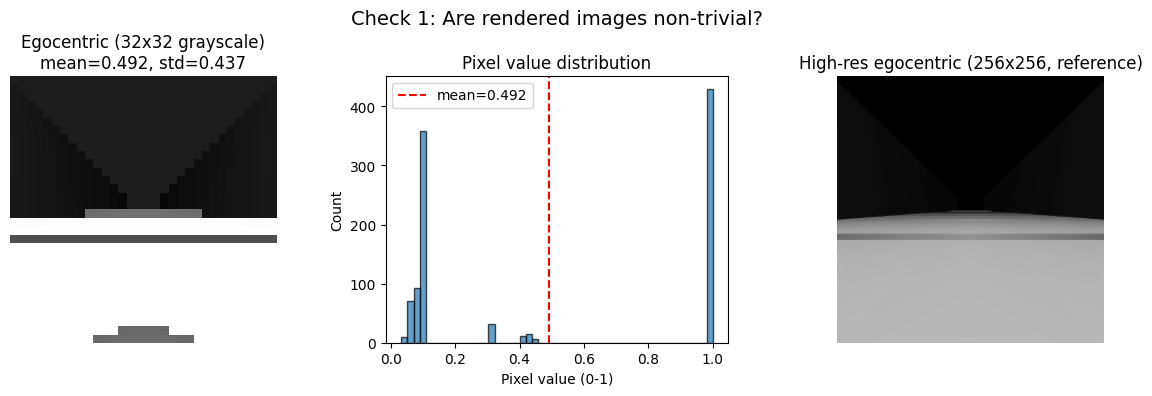

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Raw grayscale
img = np.array(vision_initial[0])  # (H, W, 1) -> remove batch dim
axes[0].imshow(img[:, :, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title(
    f"Egocentric (32x32 grayscale)\nmean={img.mean():.3f}, std={img.std():.3f}"
)
axes[0].axis("off")

# Histogram of pixel values
axes[1].hist(img.flatten(), bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Pixel value (0-1)")
axes[1].set_ylabel("Count")
axes[1].set_title("Pixel value distribution")
axes[1].axvline(x=img.mean(), color="r", linestyle="--", label=f"mean={img.mean():.3f}")
axes[1].legend()

# High-res version using MuJoCo software renderer for comparison
mj_data = mujoco.MjData(mj_model)
mj_data.qpos = np.array(state.data.qpos)
mujoco.mj_forward(mj_model, mj_data)
hires_renderer = mujoco.Renderer(mj_model, height=256, width=256)

# Hide rodent body geoms for egocentric view
rodent_body_ids = {
    i for i in range(mj_model.nbody) if mj_model.body(i).name.endswith("-rodent")
}
rodent_geom_ids = np.array(
    [i for i in range(mj_model.ngeom) if mj_model.geom_bodyid[i] in rodent_body_ids]
)
saved_groups = mj_model.geom_group[rodent_geom_ids].copy()
mj_model.geom_group[rodent_geom_ids] = 4  # hide from default render

hires_renderer.update_scene(mj_data, camera="egocentric-rodent")
hires_frame = hires_renderer.render()
mj_model.geom_group[rodent_geom_ids] = saved_groups  # restore
hires_renderer.close()

axes[2].imshow(hires_frame)
axes[2].set_title("High-res egocentric (256x256, reference)")
axes[2].axis("off")

plt.suptitle("Check 1: Are rendered images non-trivial?", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Vision Changes Over Time (Gap Approach)

Step the environment with random actions and check that:
- Vision frames change as the rodent moves
- The gap becomes visible as the rodent approaches it
- Pixel statistics vary across timesteps

In [ ]:
# Run a short rollout, rendering vision at each step
N_STEPS = 50
step_fn = jax.jit(env.step)
render_fn = jax.jit(renderer.render)

rng = jax.random.PRNGKey(123)
state = jax.jit(env.reset)(rng)

vision_frames = []
pixel_means = []
pixel_stds = []
x_positions = []

for i in tqdm(range(N_STEPS), desc="Stepping with random actions"):
    rng, act_key = jax.random.split(rng)
    # Use small random actions to get the rodent moving
    action = 0.1 * jax.random.normal(act_key, (env.action_size,))
    state = step_fn(state, action)

    # Render vision
    batched_data = jax.tree.map(lambda x: x[None, ...], state.data)
    vision = render_fn(batched_data)
    vision_np = np.array(vision[0])  # (H, W, C)

    vision_frames.append(vision_np)
    pixel_means.append(vision_np.mean())
    pixel_stds.append(vision_np.std())
    x_positions.append(float(state.data.qpos[0]))  # x position

    if state.done > 0.5:
        print(f"Episode terminated at step {i+1}")
        break

pixel_means = np.array(pixel_means)
pixel_stds = np.array(pixel_stds)
x_positions = np.array(x_positions)

print(f"\nCollected {len(vision_frames)} frames")
print(f"Pixel mean range: [{pixel_means.min():.4f}, {pixel_means.max():.4f}]")
print(f"Pixel std range: [{pixel_stds.min():.4f}, {pixel_stds.max():.4f}]")

# Check frame-to-frame variation
frame_diffs = []
for i in range(1, len(vision_frames)):
    diff = np.abs(
        vision_frames[i].astype(float) - vision_frames[i - 1].astype(float)
    ).mean()
    frame_diffs.append(diff)
frame_diffs = np.array(frame_diffs)

print(
    f"Frame-to-frame diff: mean={frame_diffs.mean():.6f}, max={frame_diffs.max():.6f}"
)
has_temporal_variation = frame_diffs.mean() > 1e-6
print(
    f"\nVISION {'CHANGES OVER TIME' if has_temporal_variation else 'IS STATIC (problem!)'}"
)

Stepping with random actions:   7%|▋         | 14/200 [00:02<00:32,  5.71it/s]

Episode terminated at step 15

Collected 15 frames
Pixel mean range: [0.1038, 0.7409]
Pixel std range: [0.0185, 0.4461]
Frame-to-frame diff: mean=0.079564, max=0.191899

VISION CHANGES OVER TIME


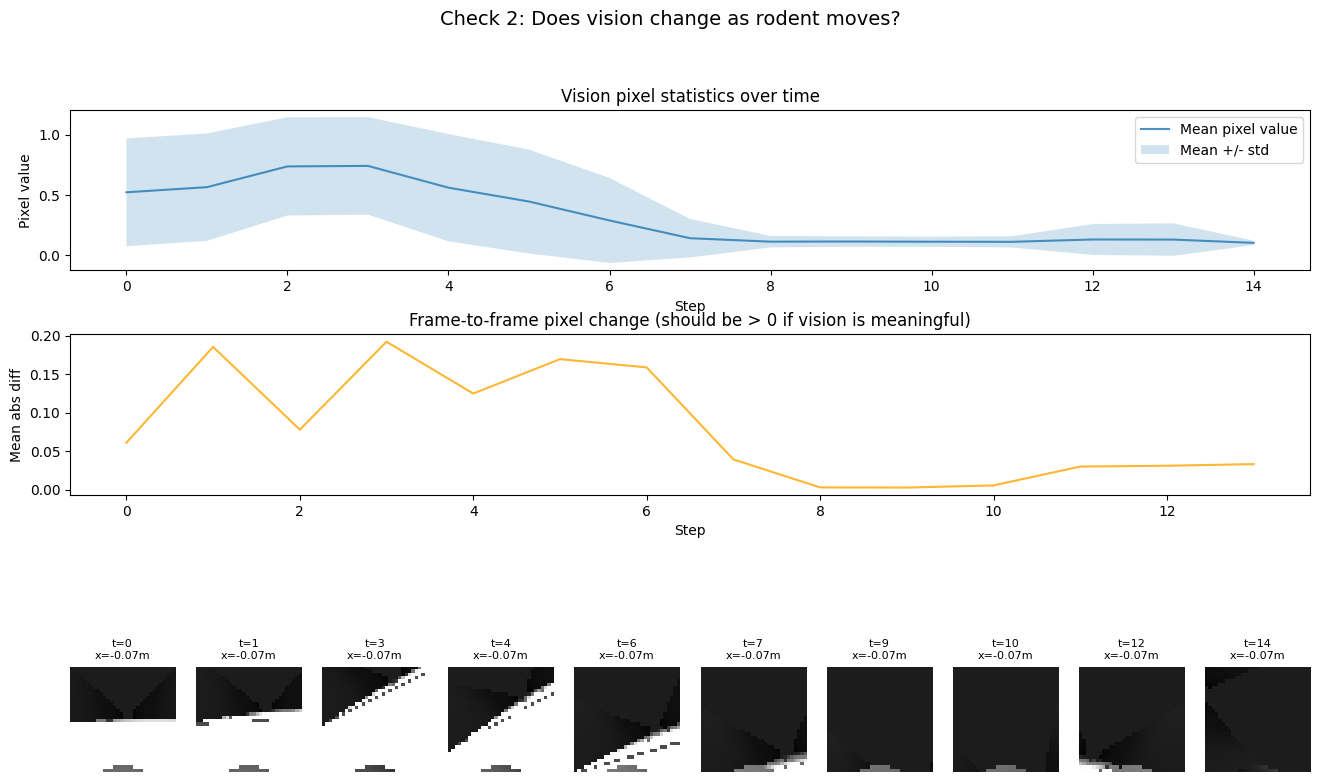

In [6]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 2], hspace=0.3)

# Top: pixel statistics over time
ax1 = fig.add_subplot(gs[0])
ax1.plot(pixel_means, label="Mean pixel value", alpha=0.8)
ax1.fill_between(
    range(len(pixel_means)),
    pixel_means - pixel_stds,
    pixel_means + pixel_stds,
    alpha=0.2,
    label="Mean +/- std",
)
ax1.set_xlabel("Step")
ax1.set_ylabel("Pixel value")
ax1.set_title("Vision pixel statistics over time")
ax1.legend()

# Middle: frame-to-frame difference
ax2 = fig.add_subplot(gs[1])
ax2.plot(frame_diffs, color="orange", alpha=0.8)
ax2.set_xlabel("Step")
ax2.set_ylabel("Mean abs diff")
ax2.set_title("Frame-to-frame pixel change (should be > 0 if vision is meaningful)")

# Bottom: sample frames at regular intervals
n_samples = min(10, len(vision_frames))
sample_idxs = np.linspace(0, len(vision_frames) - 1, n_samples, dtype=int)
gs_inner = gridspec.GridSpecFromSubplotSpec(1, n_samples, subplot_spec=gs[2])
for j, idx in enumerate(sample_idxs):
    ax = fig.add_subplot(gs_inner[0, j])
    ax.imshow(vision_frames[idx][:, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"t={idx}\nx={x_positions[idx]:.2f}m", fontsize=8)
    ax.axis("off")

plt.suptitle("Check 2: Does vision change as rodent moves?", fontsize=14)
plt.show()

## 3. CNN Feature Extraction Check

Pass rendered vision frames through the VisionEncoder CNN and verify:
- Features are non-constant (different images -> different features)
- Features have reasonable magnitude and variance
- Features change when the visual scene changes

In [7]:
# Initialize the VisionEncoder (same architecture as training)
# Training config: vision_channels=[2, 4, 8, 16], feature_size=8 (vision_latent_size)
vision_encoder = VisionEncoder(
    feature_size=8,  # vision_latent_size from config
    channels=(2, 4, 8, 16),  # vision_channels from config
)

# Init with a dummy image
dummy_img = jnp.zeros((32, 32, 1))
encoder_params = vision_encoder.init(jax.random.PRNGKey(0), dummy_img)

# Count parameters
n_params = sum(p.size for p in jax.tree_util.tree_leaves(encoder_params))
print(f"VisionEncoder params: {n_params:,}")

# Forward pass on all collected frames
vision_stack = jnp.array(np.array(vision_frames))  # (T, H, W, C)
print(f"Vision stack shape: {vision_stack.shape}")


# Batch forward pass
@jax.jit
def encode_batch(params, images):
    return jax.vmap(lambda img: vision_encoder.apply(params, img))(images)


features = encode_batch(encoder_params, vision_stack)
print(f"CNN features shape: {features.shape}")  # (T, 8)
print(f"CNN features range: [{float(features.min()):.4f}, {float(features.max()):.4f}]")
print(f"CNN features mean: {float(features.mean()):.4f}")
print(f"CNN features std: {float(features.std()):.4f}")

# Check per-dimension statistics
features_np = np.array(features)
print(f"\nPer-dimension statistics:")
for d in range(features_np.shape[1]):
    print(
        f"  dim {d}: mean={features_np[:, d].mean():.4f}, "
        f"std={features_np[:, d].std():.4f}, "
        f"range=[{features_np[:, d].min():.4f}, {features_np[:, d].max():.4f}]"
    )

# Check if features are constant
feature_std_per_dim = features_np.std(axis=0)
n_dead_dims = (feature_std_per_dim < 1e-6).sum()
print(f"\nDead dimensions (std < 1e-6): {n_dead_dims}/{features_np.shape[1]}")
print(
    f"FEATURES {'HAVE VARIATION' if n_dead_dims < features_np.shape[1] else 'ARE ALL DEAD (problem!)'}"
)

VisionEncoder params: 6,192
Vision stack shape: (15, 32, 32, 1)
CNN features shape: (15, 8)
CNN features range: [0.0000, 2.0514]
CNN features mean: 0.2842
CNN features std: 0.4432

Per-dimension statistics:
  dim 0: mean=0.7351, std=0.7309, range=[0.0000, 2.0514]
  dim 1: mean=0.3211, std=0.3594, range=[0.0000, 0.9818]
  dim 2: mean=0.2174, std=0.2446, range=[0.0000, 0.6124]
  dim 3: mean=0.1089, std=0.2832, range=[0.0000, 0.9709]
  dim 4: mean=0.1036, std=0.2075, range=[0.0000, 0.6317]
  dim 5: mean=0.2254, std=0.3634, range=[0.0000, 1.2502]
  dim 6: mean=0.2576, std=0.3753, range=[0.0000, 1.0411]
  dim 7: mean=0.3044, std=0.4180, range=[0.0000, 1.4263]

Dead dimensions (std < 1e-6): 0/8
FEATURES HAVE VARIATION


/home/talmolab/Desktop/SalkResearch/mimic-mjx/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/talmolab/Desktop/SalkResearch/mimic-mjx/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


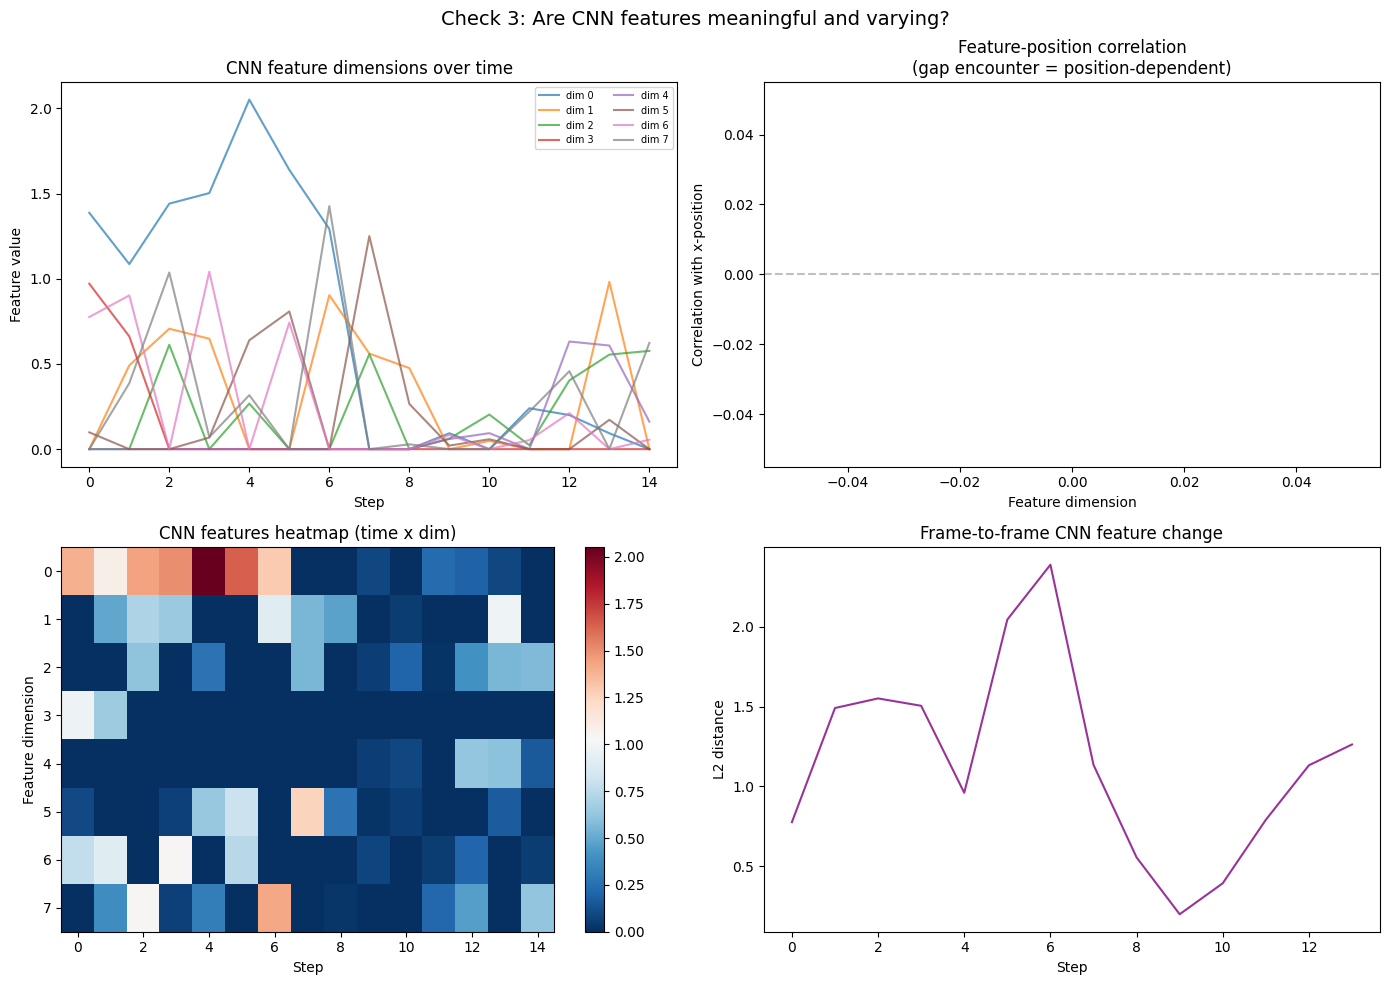

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Feature trajectories over time
for d in range(features_np.shape[1]):
    axes[0, 0].plot(features_np[:, d], label=f"dim {d}", alpha=0.7)
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Feature value")
axes[0, 0].set_title("CNN feature dimensions over time")
axes[0, 0].legend(fontsize=7, ncol=2)

# Feature correlation with x-position
for d in range(features_np.shape[1]):
    corr = np.corrcoef(x_positions[: len(features_np)], features_np[:, d])[0, 1]
    axes[0, 1].bar(d, corr, alpha=0.7)
axes[0, 1].set_xlabel("Feature dimension")
axes[0, 1].set_ylabel("Correlation with x-position")
axes[0, 1].set_title(
    "Feature-position correlation\n(gap encounter = position-dependent)"
)
axes[0, 1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Feature heatmap over time
im = axes[1, 0].imshow(
    features_np.T, aspect="auto", cmap="RdBu_r", interpolation="nearest"
)
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Feature dimension")
axes[1, 0].set_title("CNN features heatmap (time x dim)")
plt.colorbar(im, ax=axes[1, 0])

# Pairwise feature distance between frames
feature_diffs = np.diff(features_np, axis=0)
feature_diff_norms = np.linalg.norm(feature_diffs, axis=1)
axes[1, 1].plot(feature_diff_norms, color="purple", alpha=0.8)
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("L2 distance")
axes[1, 1].set_title("Frame-to-frame CNN feature change")

plt.suptitle("Check 3: Are CNN features meaningful and varying?", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Perturbation Test: Real vs. Blank vs. Scrambled Vision

The strongest test: if the CNN is extracting meaningful information, its features
should differ substantially between real rendered vision and:
- All-black (zeros) images
- All-white (ones) images
- Random noise images
- Spatially scrambled versions of the real images

In [9]:
# Pick a representative frame (one from the middle of the rollout)
mid_idx = len(vision_frames) // 2
real_frame = jnp.array(vision_frames[mid_idx])  # (H, W, C)

# Create perturbations
black_frame = jnp.zeros_like(real_frame)
white_frame = jnp.ones_like(real_frame)
noise_frame = jax.random.uniform(jax.random.PRNGKey(0), real_frame.shape)
# Scrambled: same pixels, random spatial order
flat_pixels = real_frame.reshape(-1)
scrambled_pixels = jax.random.permutation(jax.random.PRNGKey(1), flat_pixels)
scrambled_frame = scrambled_pixels.reshape(real_frame.shape)

# Encode all
frames_to_test = {
    "Real": real_frame,
    "Black (zeros)": black_frame,
    "White (ones)": white_frame,
    "Random noise": noise_frame,
    "Scrambled": scrambled_frame,
}


@jax.jit
def encode_single(params, img):
    return vision_encoder.apply(params, img)


features_perturbed = {}
for name, frame in frames_to_test.items():
    feat = encode_single(encoder_params, frame)
    features_perturbed[name] = np.array(feat)
    print(f"{name:20s}: features = {np.array(feat).round(4)}")

# L2 distances from real
print("\nL2 distance from real frame features:")
real_feat = features_perturbed["Real"]
for name, feat in features_perturbed.items():
    dist = np.linalg.norm(feat - real_feat)
    print(f"  {name:20s}: {dist:.4f}")

Real                : features = [0.     0.5607 0.5575 0.     0.     1.2502 0.     0.    ]
Black (zeros)       : features = [0. 0. 0. 0. 0. 0. 0. 0.]
White (ones)        : features = [0. 0. 0. 0. 0. 0. 0. 0.]
Random noise        : features = [2.0816 0.     0.     0.     0.0764 0.0761 0.     0.8507]
Scrambled           : features = [0.9393 0.     0.0485 0.     0.     0.1836 0.6303 1.4209]

L2 distance from real frame features:
  Real                : 0.0000
  Black (zeros)       : 1.4793
  White (ones)        : 1.4793
  Random noise        : 2.6582
  Scrambled           : 2.2383


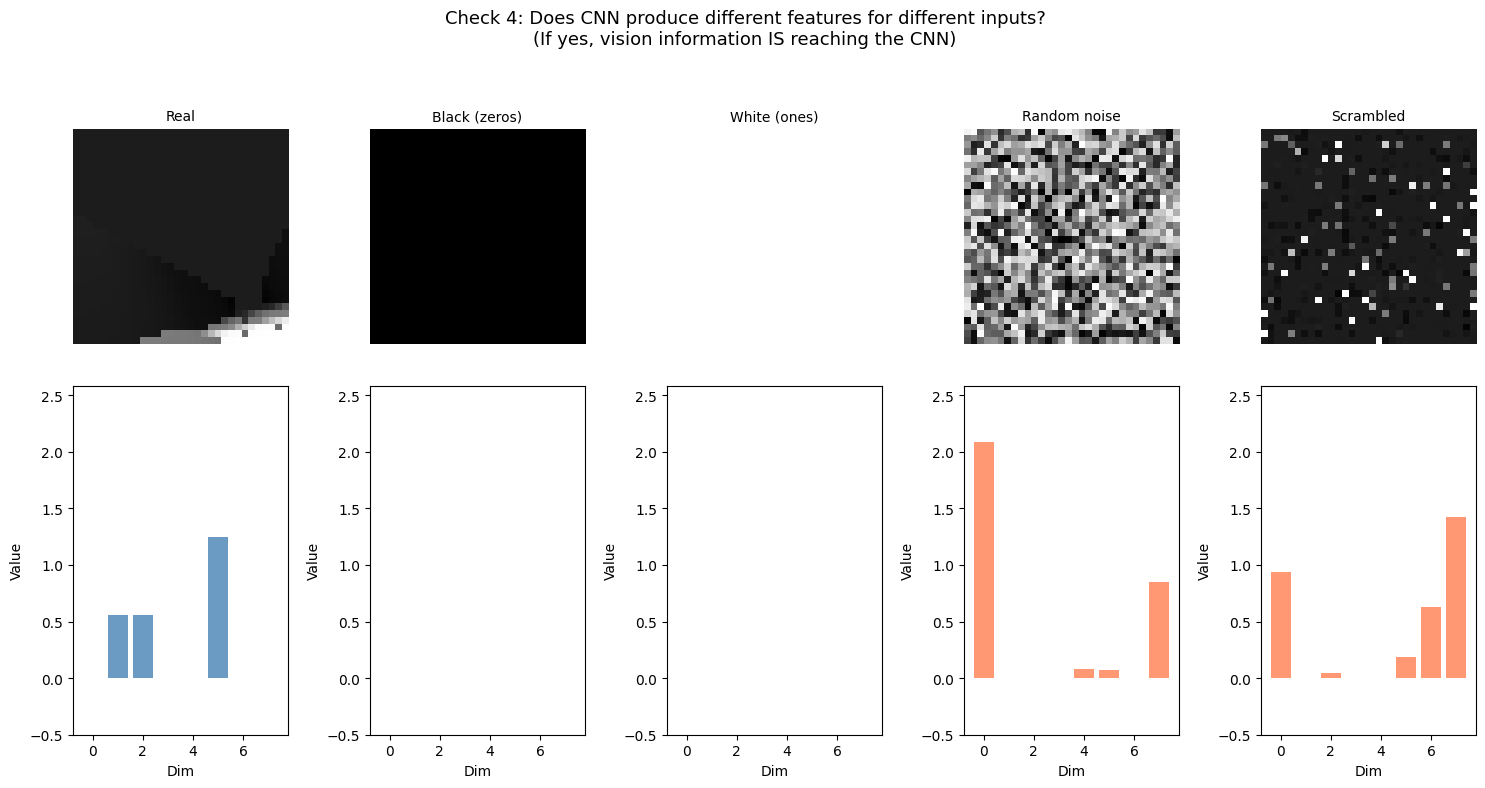


Real vs Black L2 distance: 1.4793
PASS: CNN features differ between real and blank vision


In [10]:
fig, axes = plt.subplots(2, len(frames_to_test), figsize=(3 * len(frames_to_test), 8))

for i, (name, frame) in enumerate(frames_to_test.items()):
    # Show image
    axes[0, i].imshow(np.array(frame[:, :, 0]), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(name, fontsize=10)
    axes[0, i].axis("off")

    # Show features as bar plot
    feat = features_perturbed[name]
    color = "steelblue" if name == "Real" else "coral"
    axes[1, i].bar(range(len(feat)), feat, color=color, alpha=0.8)
    axes[1, i].set_xlabel("Dim")
    axes[1, i].set_ylabel("Value")
    axes[1, i].set_ylim(
        min(f.min() for f in features_perturbed.values()) - 0.5,
        max(f.max() for f in features_perturbed.values()) + 0.5,
    )

plt.suptitle(
    "Check 4: Does CNN produce different features for different inputs?\n"
    "(If yes, vision information IS reaching the CNN)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

# Summary verdict
real_feat = features_perturbed["Real"]
black_feat = features_perturbed["Black (zeros)"]
dist_real_vs_black = np.linalg.norm(real_feat - black_feat)
print(f"\nReal vs Black L2 distance: {dist_real_vs_black:.4f}")
if dist_real_vs_black > 0.1:
    print("PASS: CNN features differ between real and blank vision")
else:
    print("FAIL: CNN features are nearly identical for real and blank vision!")
    print("  -> The CNN may not be processing vision meaningfully")

## 5. Full Pipeline Test with Trained Checkpoint (Optional)

If a trained vision checkpoint exists, load it and verify that:
- The **trained** CNN produces different features for different visual inputs
- The **policy** produces different actions when given real vs. blank vision

Set `CHECKPOINT_PATH` below, or skip this section if no checkpoint is available yet.

In [13]:
# ============================================================
# SET THIS to your checkpoint path, or set to None to skip
# ============================================================
CHECKPOINT_PATH = "/home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/260213_191036"  # e.g., "/home/talmolab/Desktop/SalkResearch/vnl-playground/model_checkpoints/XXXXXX_XXXXXX"
STEP_PREFIX = "PPONetwork"
STEP = None  # None = latest

if CHECKPOINT_PATH is not None and os.path.exists(CHECKPOINT_PATH):
    import json
    import orbax.checkpoint as ocp
    from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
    from track_mjx.agent.ff_ppo import losses as ff_ppo_losses
    from track_mjx.agent.observation_utils import (
        init_dict_normalizer,
        normalize_dict_obs,
    )
    from brax.training.acme import running_statistics, specs
    from brax.training import types as training_types

    mgr = ocp.CheckpointManager(
        CHECKPOINT_PATH,
        options=ocp.CheckpointManagerOptions(create=False, step_prefix=STEP_PREFIX),
    )
    step = STEP if STEP is not None else mgr.latest_step()
    print(f"Loading step: {step}")

    # Load config
    config_path = os.path.join(
        CHECKPOINT_PATH, f"{STEP_PREFIX}_{step}", "config", "metadata"
    )
    with open(config_path) as f:
        ckpt_cfg = json.load(f)

    net_cfg = ckpt_cfg["network_config"]
    obs_sizes = net_cfg["obs_sizes"]
    action_size = net_cfg["action_size"]
    print(f"Obs sizes: {obs_sizes}, Action size: {action_size}")

    # Auto-detect architecture from checkpoint config
    arch_name = net_cfg.get("arch_name", "vision")
    print(f"Architecture: {arch_name}")
    vision_shape = (32, 32, 1)

    if arch_name == "vision_task_obs":
        ppo_network = ff_ppo_networks.make_vision_task_obs_highlvl_ppo_networks(
            obs_sizes=obs_sizes,
            action_size=action_size,
            vision_shape=vision_shape,
            vision_latent_size=net_cfg.get("vision_latent_size", 16),
            vision_feature_size=net_cfg.get("vision_feature_size", 8),
            decoder_hidden_layer_sizes=tuple(
                net_cfg.get("decoder_hidden_layer_sizes", [512, 512])
            ),
            value_hidden_layer_sizes=tuple(
                net_cfg.get("value_hidden_layer_sizes", [512, 512])
            ),
            vision_channels=tuple(net_cfg.get("vision_channels", [2, 4, 8, 16])),
            fusion_hidden_layer_sizes=tuple(
                net_cfg.get("fusion_hidden_layer_sizes", [256])
            ),
        )
    else:
        ppo_network = ff_ppo_networks.make_vision_highlvl_ppo_networks(
            obs_sizes=obs_sizes,
            action_size=action_size,
            vision_shape=vision_shape,
            vision_latent_size=net_cfg.get("vision_latent_size", 8),
            decoder_hidden_layer_sizes=tuple(
                net_cfg.get("decoder_hidden_layer_sizes", [512, 512])
            ),
            value_hidden_layer_sizes=tuple(
                net_cfg.get("value_hidden_layer_sizes", [512, 512])
            ),
            vision_channels=tuple(net_cfg.get("vision_channels", [2, 4, 8, 16])),
        )

    # Init params
    key_p, key_v = jax.random.split(jax.random.PRNGKey(0))
    abstract_params = ff_ppo_losses.PPONetworkParams(
        policy=ppo_network.policy_network.init(key_p),
        value=ppo_network.value_network.init(key_v),
    )

    # Build normalizer — init_dict_normalizer always needs both keys
    imitation_target_size = obs_sizes.get("imitation_target", 0)
    proprioception_size = obs_sizes.get("proprioception", 0)
    dummy_obs = {
        "proprioception": jnp.zeros((1, proprioception_size)),
        "imitation_target": jnp.zeros((1, imitation_target_size)),
    }
    abstract_normalizer = init_dict_normalizer(dummy_obs)

    # Build matching abstract for restore (handle zero-sized fields)
    def _make_scalar_normalizer():
        return running_statistics.RunningStatisticsState(
            count=training_types.UInt64(hi=jnp.zeros(()), lo=jnp.zeros(())),
            mean=jnp.zeros(()),
            summed_variance=jnp.zeros(()),
            std=jnp.zeros(()),
        )

    abstract_normalizer_match = abstract_normalizer
    # Zero-sized fields get saved as scalar sentinels in checkpoints
    if proprioception_size == 0:
        abstract_normalizer_match = abstract_normalizer_match.replace(
            proprioception=_make_scalar_normalizer()
        )
    if imitation_target_size == 0:
        abstract_normalizer_match = abstract_normalizer_match.replace(
            imitation_target=_make_scalar_normalizer()
        )

    abstract_policy_match = (abstract_normalizer_match, abstract_params.policy)

    restored = mgr.restore(
        step,
        args=ocp.args.Composite(
            policy=ocp.args.StandardRestore(abstract_policy_match),
        ),
    )
    normalizer_state, policy_params = restored["policy"]

    # Fix zero-sized normalizer fields back to proper shape
    if proprioception_size == 0:
        normalizer_state = normalizer_state.replace(
            proprioception=running_statistics.init_state(
                specs.Array((0,), jnp.dtype("float32"))
            )
        )
    if imitation_target_size == 0:
        normalizer_state = normalizer_state.replace(
            imitation_target=running_statistics.init_state(
                specs.Array((0,), jnp.dtype("float32"))
            )
        )

    print(f"Checkpoint loaded from step {step}")
    CHECKPOINT_LOADED = True
else:
    print("No checkpoint path set or path not found. Skipping checkpoint-based tests.")
    print("Set CHECKPOINT_PATH above to enable this section.")
    CHECKPOINT_LOADED = False

Loading step: 10
Obs sizes: {'imitation_target': 54, 'proprioception': 0, 'vision': 1024}, Action size: 16
Architecture: vision_task_obs
Checkpoint loaded from step 10


Action with real vision:  mean=0.1341, std=0.7224
Action with blank vision: mean=0.1336, std=0.7214
Action difference: mean_abs_diff=0.0024, max_abs_diff=0.0089
Action L2 distance: 0.0138

WARN: Policy actions barely differ between real and blank vision
  -> The trained policy may not be using vision information effectively


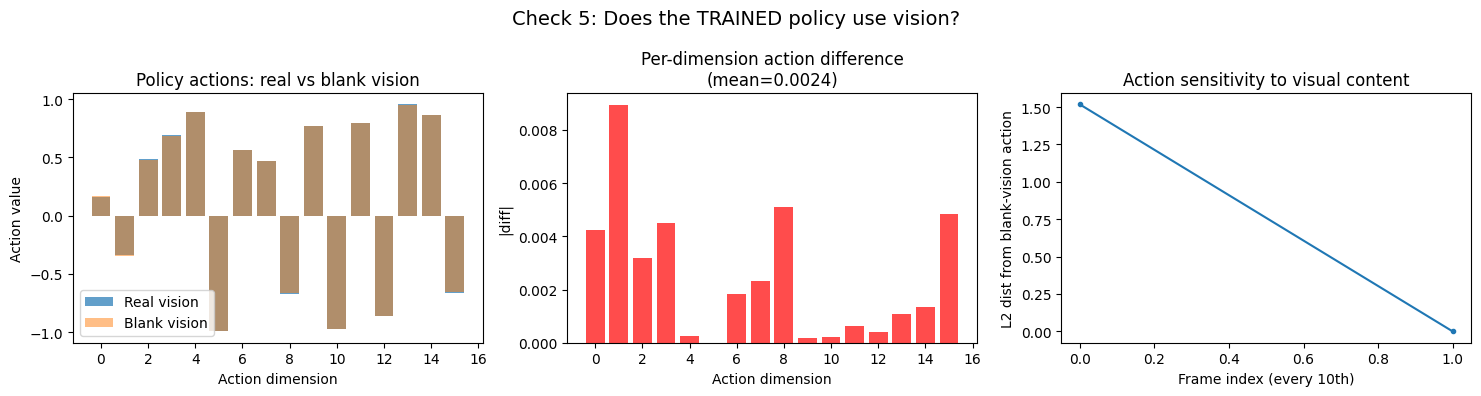

In [14]:
if CHECKPOINT_LOADED:
    # Build inference function
    make_policy = ff_ppo_networks.make_inference_fn(ppo_network)
    inference_fn = make_policy(
        (normalizer_state, policy_params),
        deterministic=True,
    )
    jit_inference = jax.jit(inference_fn)

    # Build observations with real vision vs. blank vision
    # Match obs structure from checkpoint: obs_sizes tells us the shape of each key
    real_vision = jnp.array(vision_frames[mid_idx])  # (H, W, C)
    blank_vision = jnp.zeros_like(real_vision)

    # Use correct sizes from checkpoint config
    _proprio_size = obs_sizes.get("proprioception", 0)
    _imit_size = obs_sizes.get("imitation_target", 0)

    obs_real = {
        "proprioception": jnp.zeros((_proprio_size,)),
        "imitation_target": jnp.zeros((_imit_size,)),
        "vision": real_vision,
    }
    obs_blank = {
        "proprioception": jnp.zeros((_proprio_size,)),
        "imitation_target": jnp.zeros((_imit_size,)),
        "vision": blank_vision,
    }

    rng_key = jax.random.PRNGKey(0)
    action_real, _ = jit_inference(obs_real, rng_key)
    action_blank, _ = jit_inference(obs_blank, rng_key)

    action_real_np = np.array(action_real)
    action_blank_np = np.array(action_blank)

    action_diff = np.abs(action_real_np - action_blank_np)
    print(
        f"Action with real vision:  mean={action_real_np.mean():.4f}, std={action_real_np.std():.4f}"
    )
    print(
        f"Action with blank vision: mean={action_blank_np.mean():.4f}, std={action_blank_np.std():.4f}"
    )
    print(
        f"Action difference: mean_abs_diff={action_diff.mean():.4f}, max_abs_diff={action_diff.max():.4f}"
    )
    print(f"Action L2 distance: {np.linalg.norm(action_real_np - action_blank_np):.4f}")

    if action_diff.mean() > 0.01:
        print("\nPASS: Policy produces different actions for real vs. blank vision")
    else:
        print("\nWARN: Policy actions barely differ between real and blank vision")
        print("  -> The trained policy may not be using vision information effectively")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(
        range(len(action_real_np)), action_real_np, alpha=0.7, label="Real vision"
    )
    axes[0].bar(
        range(len(action_blank_np)), action_blank_np, alpha=0.5, label="Blank vision"
    )
    axes[0].set_xlabel("Action dimension")
    axes[0].set_ylabel("Action value")
    axes[0].set_title("Policy actions: real vs blank vision")
    axes[0].legend()

    axes[1].bar(range(len(action_diff)), action_diff, color="red", alpha=0.7)
    axes[1].set_xlabel("Action dimension")
    axes[1].set_ylabel("|diff|")
    axes[1].set_title(
        f"Per-dimension action difference\n(mean={action_diff.mean():.4f})"
    )

    # Test across multiple frames
    dists = []
    for frame in vision_frames[::10]:
        obs_test = {
            "proprioception": jnp.zeros((_proprio_size,)),
            "imitation_target": jnp.zeros((_imit_size,)),
            "vision": jnp.array(frame),
        }
        act, _ = jit_inference(obs_test, rng_key)
        dists.append(np.linalg.norm(np.array(act) - action_blank_np))
    axes[2].plot(dists, marker="o", markersize=3)
    axes[2].set_xlabel("Frame index (every 10th)")
    axes[2].set_ylabel("L2 dist from blank-vision action")
    axes[2].set_title("Action sensitivity to visual content")

    plt.suptitle("Check 5: Does the TRAINED policy use vision?", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping trained checkpoint test (no checkpoint loaded)")

## Summary

All diagnostic checks and their results.

In [ ]:
print("=" * 60)
print("VISION PIPELINE VALIDATION SUMMARY")
print("=" * 60)

# Check 1: Non-trivial rendering
check1 = float(jnp.array(vision_frames[0]).std()) > 1e-6
print(f"[{'PASS' if check1 else 'FAIL'}] Check 1: Rendered images are non-trivial")

# Check 2: Temporal variation
check2 = np.array(frame_diffs).mean() > 1e-6
print(f"[{'PASS' if check2 else 'FAIL'}] Check 2: Vision changes over time")

# Check 3: CNN feature variation
check3 = n_dead_dims < features_np.shape[1]
print(f"[{'PASS' if check3 else 'FAIL'}] Check 3: CNN produces varying features ({features_np.shape[1] - n_dead_dims}/{features_np.shape[1]} active dims)")

# Check 4: Perturbation sensitivity
check4 = dist_real_vs_black > 0.1
print(f"[{'PASS' if check4 else 'FAIL'}] Check 4: CNN distinguishes real vs blank vision (L2={dist_real_vs_black:.4f})")

# Check 5: Trained policy (if available)
if CHECKPOINT_LOADED:
    check5 = action_diff.mean() > 0.01
    print(f"[{'PASS' if check5 else 'WARN'}] Check 5: Trained policy responds to vision (mean |diff|={action_diff.mean():.4f})")
else:
    print(f"[SKIP] Check 5: Trained policy test (no checkpoint loaded)")

print("=" * 60)

all_passed = check1 and check2 and check3 and check4
if all_passed:
    print("RESULT: Vision pipeline appears healthy.")
    print("  If the rodent still fails at gaps, the issue may be:")
    print("  - Insufficient training time")
    print("  - CNN capacity too small (vision_latent_size=8)")
    print("  - Gap too small to resolve at 32x32 resolution")
    print("  - Learning rate / reward shaping issues")
else:
    print("RESULT: Vision pipeline has issues that need investigation.")
    failing = []
    if not check1: failing.append("rendering produces blank images")
    if not check2: failing.append("vision is static (no temporal variation)")
    if not check3: failing.append("CNN produces dead features")
    if not check4: failing.append("CNN can't distinguish real vs blank vision")
    print(f"  Issues: {', '.join(failing)}")